<a href="https://colab.research.google.com/github/ahmad1bakundi-ops/data-engineering-journey/blob/main/ngn-fx-project/ngn_fx_project_03_visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
PROJECT_PATH = '/content/drive/MyDrive/data-engineering-journey/ngn-fx-project/'

# The daily cleaned FX data
fx = pd.read_csv(
    PROJECT_PATH + 'ngn_fx_daily_clean.csv',
    index_col='Date',
    parse_dates=['Date']
)

# The yearly analysis with percentage changes and spread
yoy = pd.read_csv(
    PROJECT_PATH + 'ngn_fx_yearly_analysis.csv',
    index_col='Date',
    parse_dates=['Date']
)

# The 2023-2024 monthly change data
mom = pd.read_csv(
    PROJECT_PATH + 'ngn_fx_2023_2024_monthly.csv',
    index_col='Date',
    parse_dates=['Date']
)

print('fx:', fx.shape)
print('yoy:', yoy.shape)
print('mom:', mom.shape)

fx: (2607, 3)
yoy: (10, 4)
mom: (24, 3)


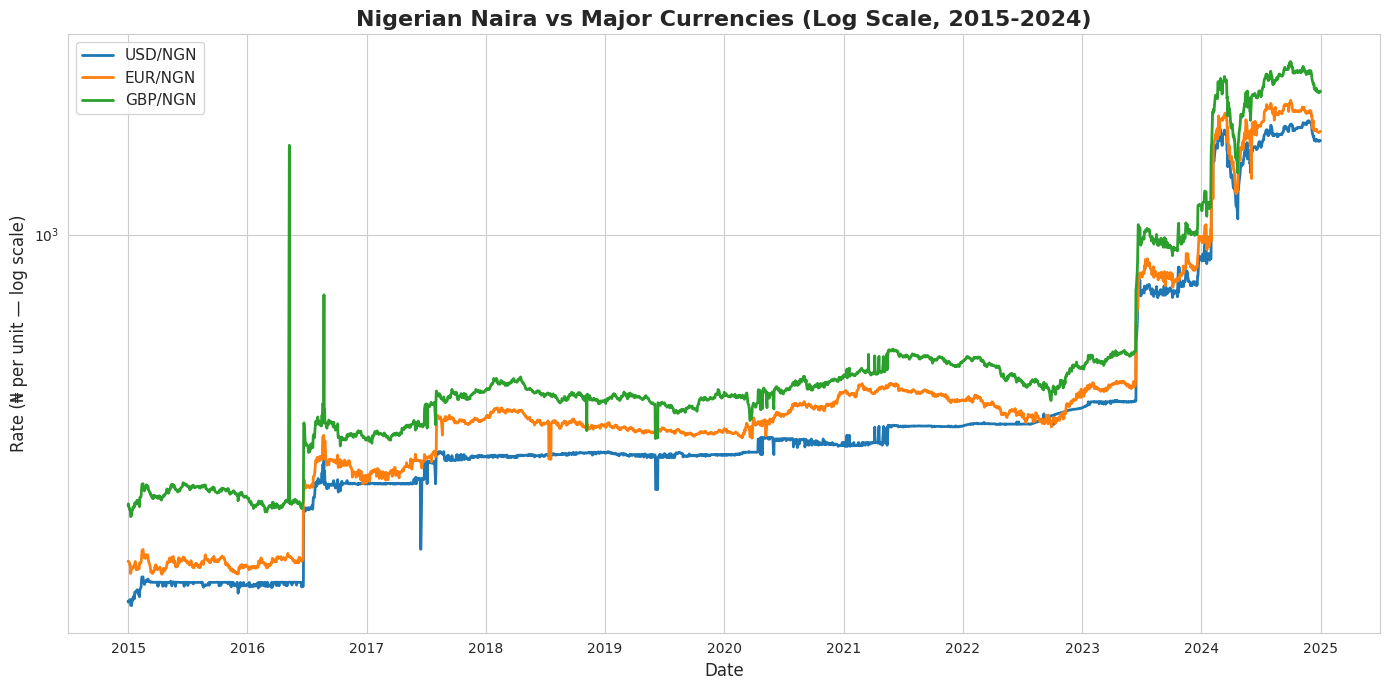

In [4]:
plt.figure(figsize=(14, 7))

plt.plot(fx.index, fx['USD'], label='USD/NGN', linewidth=2)
plt.plot(fx.index, fx['EUR'], label='EUR/NGN', linewidth=2)
plt.plot(fx.index, fx['GBP'], label='GBP/NGN', linewidth=2)

# The magic line — switch y-axis to logarithmic
plt.yscale('log')

plt.title('Nigerian Naira vs Major Currencies (Log Scale, 2015-2024)', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Rate (₦ per unit — log scale)', fontsize=12)
plt.legend(fontsize=11)

plt.tight_layout()
plt.show()

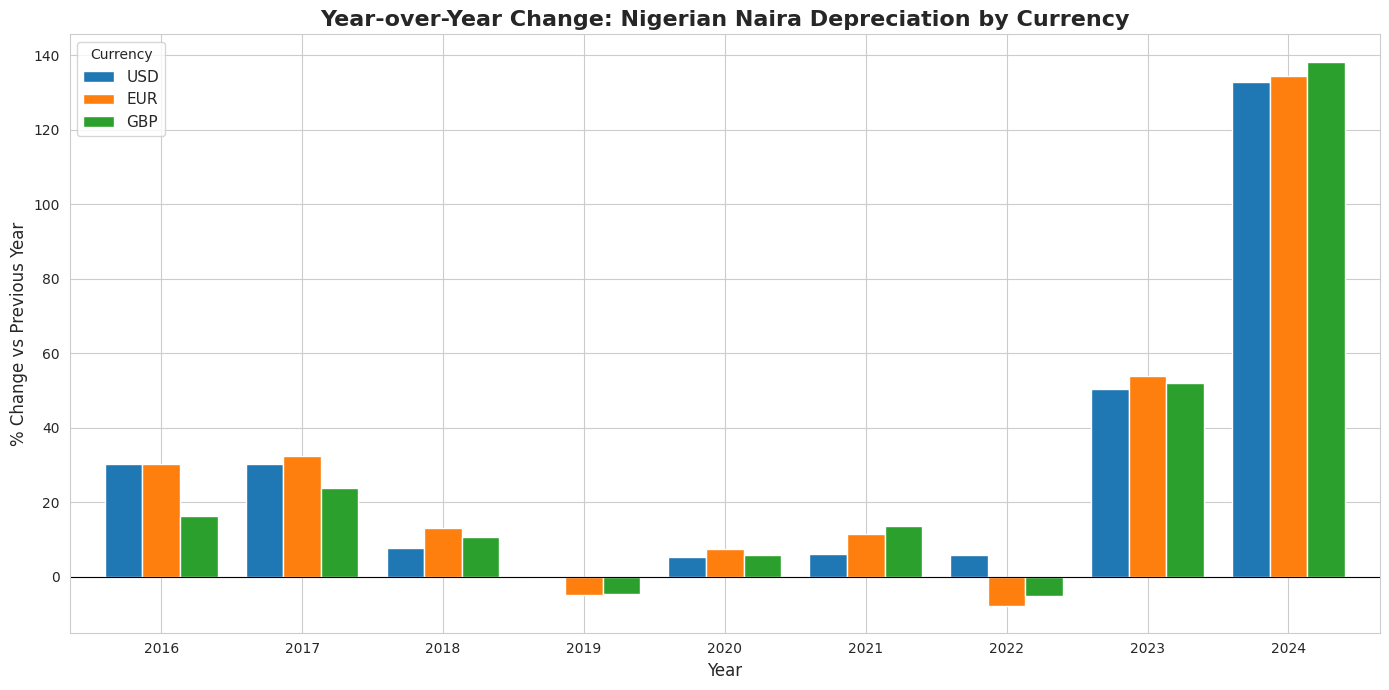

In [5]:
# Clean the yoy data for plotting: drop the spread column and the NaN 2015 row
yoy_plot = yoy[['USD', 'EUR', 'GBP']].dropna()

# Create the bar chart
plt.figure(figsize=(14, 7))

# Grouped bar chart — three bars per year
yoy_plot.plot(kind='bar', ax=plt.gca(), width=0.8)

plt.title('Year-over-Year Change: Nigerian Naira Depreciation by Currency', fontsize=16, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('% Change vs Previous Year', fontsize=12)
plt.axhline(y=0, color='black', linewidth=0.8)  # zero line for reference

# Make x-axis labels readable (dates rendered as text)
plt.xticks(
    ticks=range(len(yoy_plot)),
    labels=[str(d.year) for d in yoy_plot.index],
    rotation=0
)

plt.legend(title='Currency', fontsize=11)
plt.tight_layout()
plt.show()

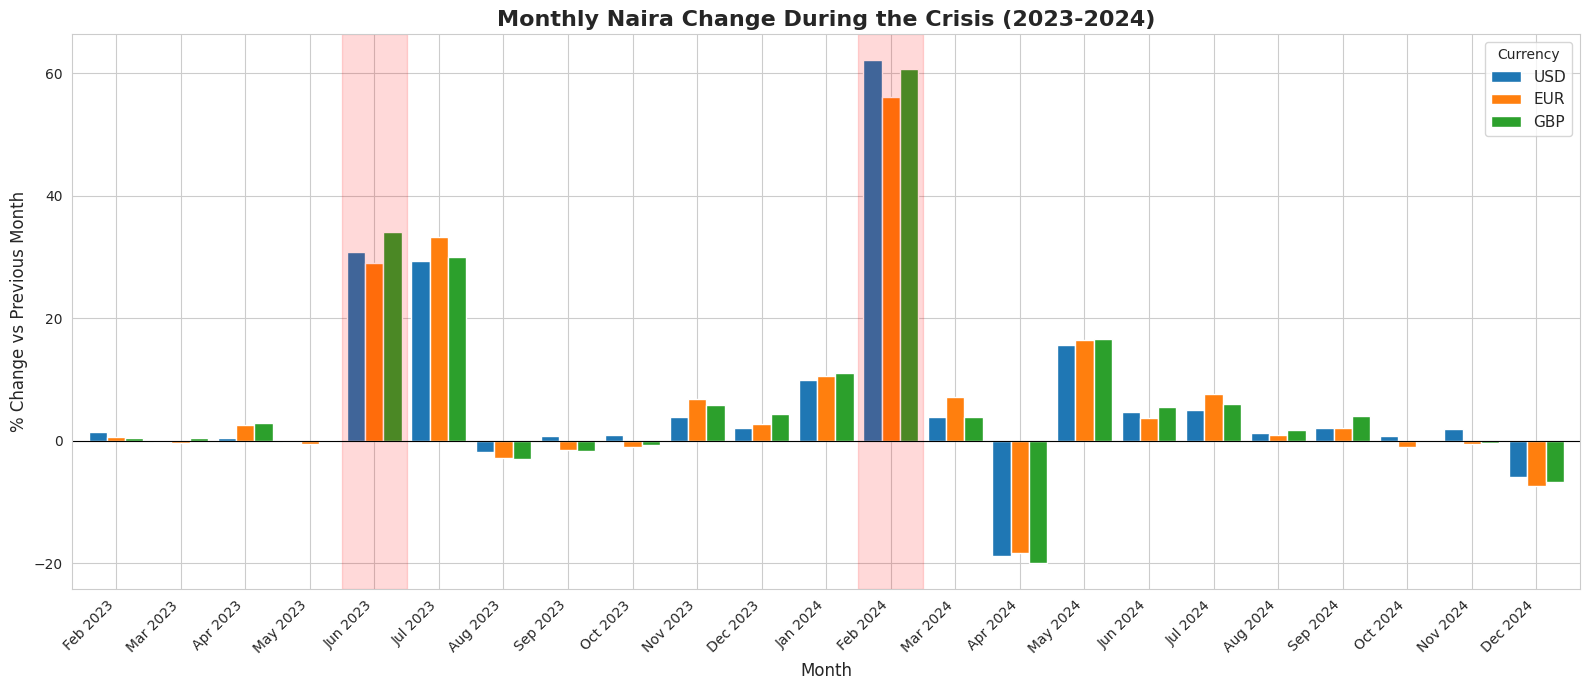

In [7]:
mom_plot = mom[['USD', 'EUR', 'GBP']].dropna()

plt.figure(figsize=(16, 7))
mom_plot.plot(kind='bar', ax=plt.gca(), width=0.85)

plt.title('Monthly Naira Change During the Crisis (2023-2024)', fontsize=16, fontweight='bold')
plt.xlabel('Month', fontsize=12)
plt.ylabel('% Change vs Previous Month', fontsize=12)
plt.axhline(y=0, color='black', linewidth=0.8)

plt.xticks(
    ticks=range(len(mom_plot)),
    labels=[d.strftime('%b %Y') for d in mom_plot.index],
    rotation=45,
    ha='right'
)

# Find the positions of June 2023 and February 2024 dynamically
jun_2023_pos = mom_plot.index.get_loc('2023-06-30')
feb_2024_pos = mom_plot.index.get_loc('2024-02-29')

# Highlight around those positions
plt.axvspan(jun_2023_pos - 0.5, jun_2023_pos + 0.5, alpha=0.15, color='red')
plt.axvspan(feb_2024_pos - 0.5, feb_2024_pos + 0.5, alpha=0.15, color='red')

plt.legend(title='Currency', fontsize=11)
plt.tight_layout()
plt.show()

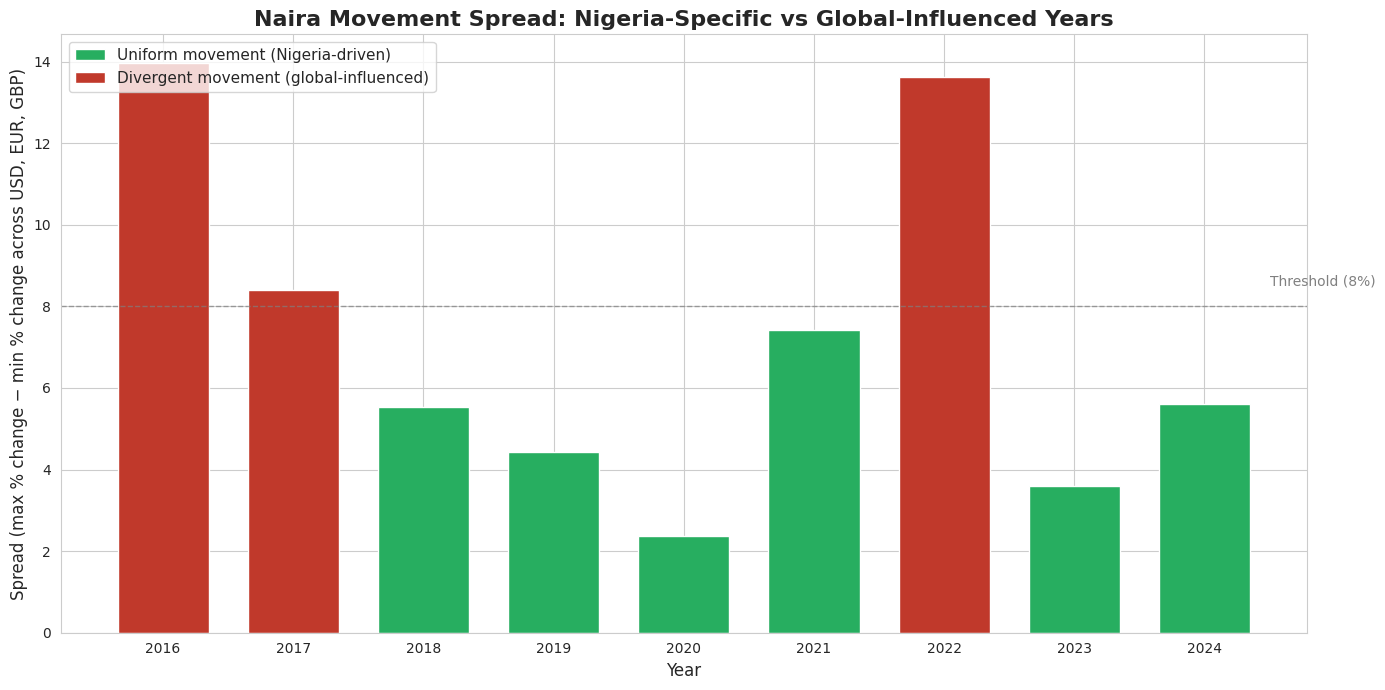

In [8]:
# Prepare data — drop the NaN 2015 row
spread_plot = yoy['spread'].dropna()

# Classify each year: "low spread" = Nigeria story, "high spread" = global influence
# Threshold at 8: below = uniform (Nigeria), above = divergent (global)
colors = ['#c0392b' if s > 8 else '#27ae60' for s in spread_plot]

# Build the chart
plt.figure(figsize=(14, 7))
plt.bar(range(len(spread_plot)), spread_plot.values, color=colors, width=0.7)

# Title and axes
plt.title('Naira Movement Spread: Nigeria-Specific vs Global-Influenced Years',
          fontsize=16, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Spread (max % change − min % change across USD, EUR, GBP)', fontsize=12)

# X-axis labels as years
plt.xticks(
    ticks=range(len(spread_plot)),
    labels=[str(d.year) for d in spread_plot.index],
    rotation=0
)

# Add a horizontal reference line at the threshold
plt.axhline(y=8, color='gray', linestyle='--', linewidth=1, alpha=0.7)
plt.text(8.5, 8.5, 'Threshold (8%)', fontsize=10, color='gray')

# Custom legend using colored patches
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#27ae60', label='Uniform movement (Nigeria-driven)'),
    Patch(facecolor='#c0392b', label='Divergent movement (global-influenced)')
]
plt.legend(handles=legend_elements, fontsize=11, loc='upper left')

plt.tight_layout()
plt.show()

In [9]:
yoy['spread'].dropna().sort_values()

,spread
Date,
2020-12-31,2.375543
2023-12-31,3.600217
2019-12-31,4.437131
2018-12-31,5.537890
2024-12-31,5.595198
2021-12-31,7.418861
2017-12-31,8.399525
2022-12-31,13.625623
2016-12-31,13.968778


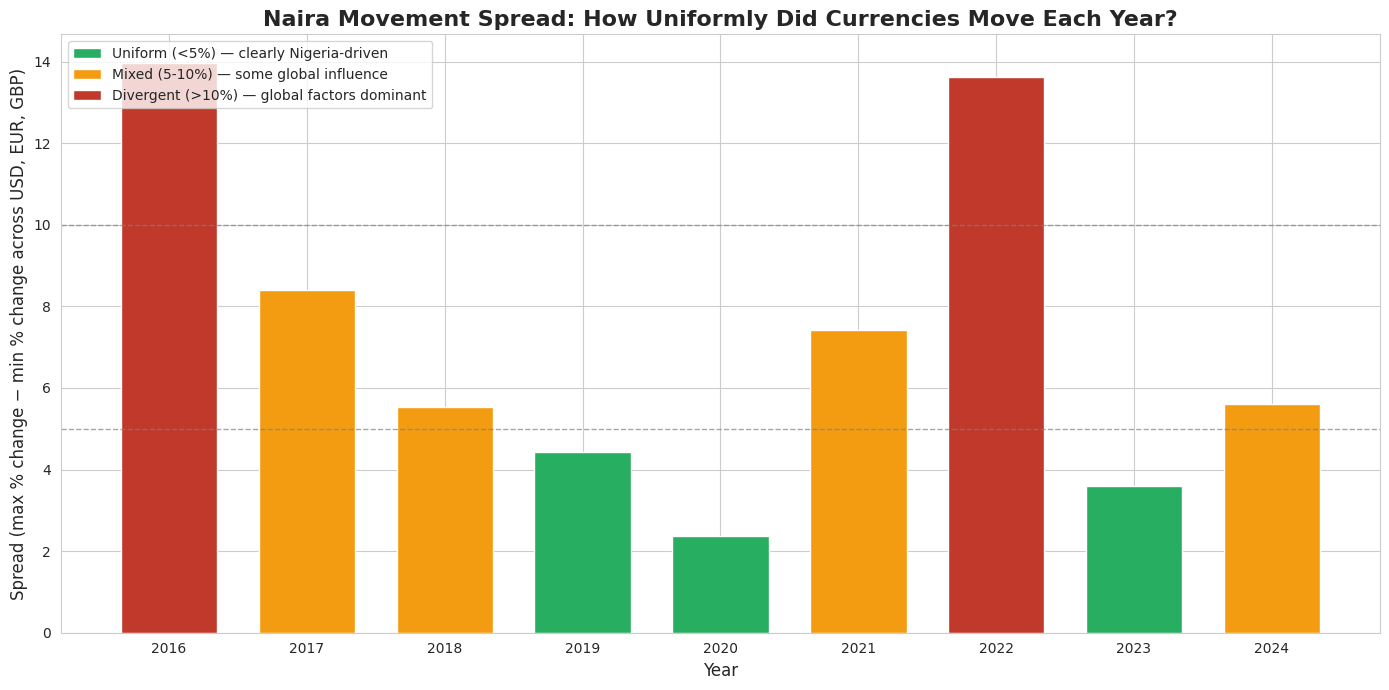

In [11]:
# Prepare data
spread_plot = yoy['spread'].dropna()

# Three-tier classification
def classify_spread(s):
    if s < 5:
        return '#27ae60'  # green — clearly Nigeria-driven
    elif s < 10:
        return '#f39c12'  # orange — mixed
    else:
        return '#c0392b'  # red — clearly global-influenced

colors = [classify_spread(s) for s in spread_plot]

# Build the chart
plt.figure(figsize=(14, 7))
plt.bar(range(len(spread_plot)), spread_plot.values, color=colors, width=0.7)

# Title and axes
plt.title('Naira Movement Spread: How Uniformly Did Currencies Move Each Year?',
          fontsize=16, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Spread (max % change − min % change across USD, EUR, GBP)', fontsize=12)

# X-axis labels as years
plt.xticks(
    ticks=range(len(spread_plot)),
    labels=[str(d.year) for d in spread_plot.index],
    rotation=0
)

# Reference lines at both thresholds
plt.axhline(y=5, color='gray', linestyle='--', linewidth=1, alpha=0.7)
plt.axhline(y=10, color='gray', linestyle='--', linewidth=1, alpha=0.7)

# Custom legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#27ae60', label='Uniform (<5%) — clearly Nigeria-driven'),
    Patch(facecolor='#f39c12', label='Mixed (5-10%) — some global influence'),
    Patch(facecolor='#c0392b', label='Divergent (>10%) — global factors dominant')
]
plt.legend(handles=legend_elements, fontsize=10, loc='upper left')

plt.tight_layout()
plt.show()

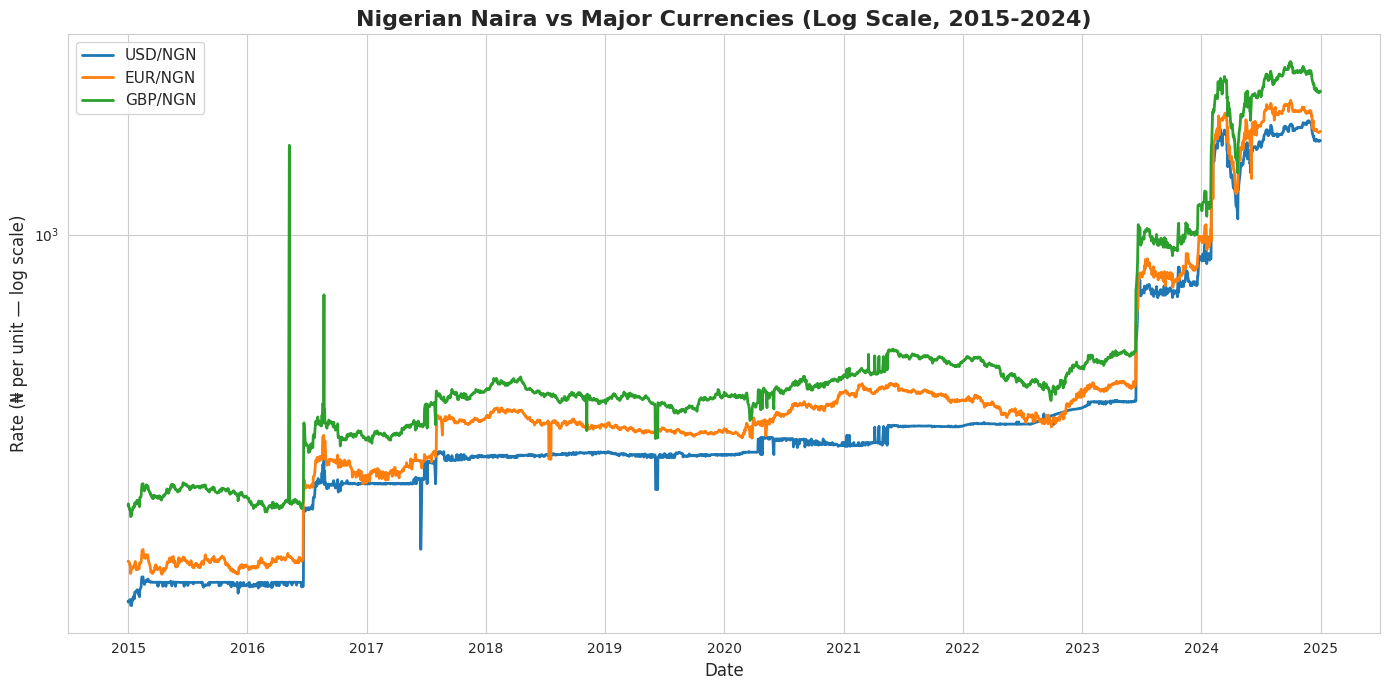

In [12]:
sns.set_style('whitegrid')

plt.figure(figsize=(14, 7))
plt.plot(fx.index, fx['USD'], label='USD/NGN', linewidth=2)
plt.plot(fx.index, fx['EUR'], label='EUR/NGN', linewidth=2)
plt.plot(fx.index, fx['GBP'], label='GBP/NGN', linewidth=2)
plt.yscale('log')
plt.title('Nigerian Naira vs Major Currencies (Log Scale, 2015-2024)', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Rate (₦ per unit — log scale)', fontsize=12)
plt.legend(fontsize=11)
plt.tight_layout()

# Save to file BEFORE plt.show()
plt.savefig(PROJECT_PATH + 'chart_01_10year_journey.png', dpi=150, bbox_inches='tight')

plt.show()

In [13]:
# Chart 2
plt.savefig(PROJECT_PATH + 'chart_02_year_over_year.png', dpi=150, bbox_inches='tight')

# Chart 3
plt.savefig(PROJECT_PATH + 'chart_03_crisis_months.png', dpi=150, bbox_inches='tight')

# Chart 4 — 2-color version (for LinkedIn)
plt.savefig(PROJECT_PATH + 'chart_04a_spread_2color.png', dpi=150, bbox_inches='tight')

# Chart 4 — 3-color version (for portfolio)
plt.savefig(PROJECT_PATH + 'chart_04b_spread_3color.png', dpi=150, bbox_inches='tight')

<Figure size 640x480 with 0 Axes>

In [15]:
import os
files = [f for f in os.listdir(PROJECT_PATH) if f.endswith('.png')]
files

['chart_01_10year_journey.png',
 'chart_02_year_over_year.png',
 'chart_03_crisis_months.png',
 'chart_04a_spread_2color.png',
 'chart_04b_spread_3color.png']